# Churn Prediction Modeling

The goal of this stage is to build a predictive model that identifies customers at risk of churn.

While earlier analysis focused on identifying churn drivers and revenue risk segments, this step focuses on predicting which customers are most likely to churn in the future.

Two models are developed and compared:

• Logistic Regression (baseline interpretable model)  
• Random Forest (ensemble model for improved predictive performance)

Target variable: `churn_flag`

In [28]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, precision_score, f1_score, recall_score, confusion_matrix, RocCurveDisplay

In [3]:
df = pd.read_csv("../data/telco_churn_cleaned_v1.csv")

df.head().T

,0,1,2,3,4
gender,Female,Male,Male,Male,Female
senior_citizen,0,0,0,0,0
partner,Yes,No,No,No,No
dependents,No,No,No,No,No
tenure,1,34,2,45,2
phone_service,No,Yes,Yes,No,Yes
multiple_lines,No phone service,No,No,No phone service,No
internet_service,DSL,DSL,DSL,DSL,Fiber optic
online_security,No,Yes,Yes,Yes,No
online_backup,Yes,No,Yes,No,No


In [4]:
df = df.drop(columns=["churn"])

In [5]:
Y = df['churn_flag']
X = df.drop(columns=["churn_flag"])

In [6]:
X = pd.get_dummies(X, drop_first=True)

In [7]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)

In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, Y_train)
Y_pred_log = log_model.predict(X_test_scaled)
Y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]

In [9]:
print("Accuracy:", accuracy_score(Y_test, Y_pred_log))
print("ROC AUC:", roc_auc_score(Y_test, Y_prob_log))
print(classification_report(Y_test, Y_pred_log))

Accuracy: 0.7984386089425124
ROC AUC: 0.842721330956625
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [10]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, Y_train)
Y_pred_rf = rf_model.predict(X_test)
Y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [11]:
print("Accuracy:", accuracy_score(Y_test, Y_pred_rf))
print("ROC AUC:", roc_auc_score(Y_test, Y_prob_rf))
print(classification_report(Y_test, Y_pred_rf))

Accuracy: 0.794180269694819
ROC AUC: 0.8252202330207444
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409



In [12]:
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
feature_importance.head(10)

total_charges                      0.180588
monthly_charges                    0.162065
tenure                             0.149358
internet_service_Fiber optic       0.042708
payment_method_Electronic check    0.039888
gender_Male                        0.028336
contract_Two year                  0.027779
paperless_billing_Yes              0.026787
tenure_group_48+                   0.023822
partner_Yes                        0.023409
dtype: float64

In [27]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(Y_test, Y_pred_log),
        accuracy_score(Y_test, Y_pred_rf)
    ],
    "Precision": [
        precision_score(Y_test, Y_pred_log),
        precision_score(Y_test, Y_pred_rf)
    ],
    "Recall": [
        recall_score(Y_test, Y_pred_log),
        recall_score(Y_test, Y_pred_rf)
    ],
    "F1-Score": [
        f1_score(Y_test, Y_pred_log),
        f1_score(Y_test, Y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(Y_test, Y_prob_log),
        roc_auc_score(Y_test, Y_prob_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.798439,0.650000,0.521390,0.578635,0.842287
1,Random Forest,0.794180,0.641892,0.508021,0.567164,0.825220


In [21]:
print("Logistic Regression Confusion Matrix")
print(confusion_matrix(Y_test, Y_pred_log))

print("Random Forest Confusion Matrix")
print(confusion_matrix(Y_test, Y_pred_rf))

Logistic Regression Confusion Matrix
[[930 105]
 [179 195]]
Random Forest Confusion Matrix
[[929 106]
 [184 190]]


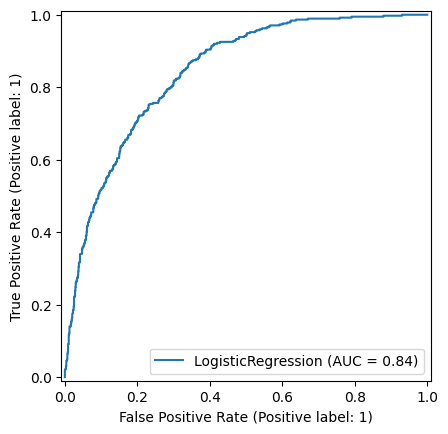

In [29]:
RocCurveDisplay.from_estimator(log_model, X_test_scaled, Y_test)

## Business Insights

Both models confirm earlier analytical findings that contract type, tenure, monthly charges, and payment behavior are strong churn predictors.

Logistic Regression slightly outperformed Random Forest on this dataset in both accuracy and ROC-AUC, while also being more interpretable.

This suggests that customer churn in this dataset is driven by relatively stable and explainable relationships, making Logistic Regression a strong baseline model for churn risk prediction.

## Business Application

Customers with high predicted churn probability can be targeted with proactive retention strategies.

Recommended actions:
- Early lifecycle engagement for new customers
- Contract upgrade incentives for month-to-month users
- Pricing/value interventions for high monthly charge customers

Predictive modeling enables the business to move from reactive churn reporting to proactive churn prevention.